In [86]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from torchvision import datasets, transforms
from PIL import Image

from sklearn.metrics import confusion_matrix

In [87]:
!git clone https://github.com/bittubiral/220120_CNN.git


fatal: destination path '220120_CNN' already exists and is not an empty directory.


In [88]:
import os

# Remove any old copy of the repository
!rm -rf /content/220120_CNN

# Clone the latest version of the GitHub repository
!git clone https://github.com/bittubiral/220120_CNN.git

# Repository path
REPO_PATH = "/content/220120_CNN"

# Custom image folder
CUSTOM_DATA_PATH = os.path.join(
    REPO_PATH,
    "custom dataset"
)

# Saved model path
MODEL_PATH = os.path.join(
    REPO_PATH,
    "model",
    "220120.pth"
)

print("Repository:", REPO_PATH)
print("Custom images:", CUSTOM_DATA_PATH)
print("Model:", MODEL_PATH)

Cloning into '220120_CNN'...
remote: Enumerating objects: 123, done.
remote: Counting objects: 100% (123/123), done.
remote: Compressing objects: 100% (112/112), done.
remote: Total 123 (delta 27), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (123/123), 12.47 MiB | 17.81 MiB/s, done.
Resolving deltas: 100% (27/27), done.
Repository: /content/220120_CNN
Custom images: /content/220120_CNN/custom dataset
Model: /content/220120_CNN/model/220120.pth


In [89]:
custom_images = []

for filename in sorted(os.listdir(CUSTOM_DATA_PATH)):

    if filename.lower().endswith(
        (".jpg", ".jpeg", ".png")
    ):

        custom_images.append(
            os.path.join(
                CUSTOM_DATA_PATH,
                filename
            )
        )

print("Custom images found:", len(custom_images))

for image_path in custom_images:
    print(os.path.basename(image_path))

Custom images found: 11
bag2.jpg
bag3.jpg
bag7.jpeg
sneaker3.jpg
sneaker9.jpeg
top1.jpg
top10.jpeg
top3.jpg
top4.jpg
touser10.jpeg
trouser3.jpg


In [90]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cpu


In [91]:
CLASS_NAMES = [
    "T-shirt/top",
    "Trouser",
    "Sneaker",
    "Bag"
]

# Original FashionMNIST labels
ORIGINAL_LABELS = [0, 1, 7, 8]

# Mapping original labels -> our labels
LABEL_MAPPING = {
    0: 0,   # T-shirt/top
    1: 1,   # Trouser
    7: 2,   # Sneaker
    8: 3    # Bag
}

print(CLASS_NAMES)

['T-shirt/top', 'Trouser', 'Sneaker', 'Bag']


In [92]:

from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [93]:
from torchvision import datasets
train_full = datasets.FashionMNIST(
    root="/content/data",
    train=True,
    download=True,
    transform=transform
)

test_full = datasets.FashionMNIST(
    root="/content/data",
    train=False,
    download=True,
    transform=transform
)

print("Training images:", len(train_full))
print("Test images:", len(test_full))

Training images: 60000
Test images: 10000


In [94]:
from torch.utils.data import Dataset
class FilteredFashionMNIST(Dataset):

    def __init__(self, base_dataset):
        self.base_dataset = base_dataset

        self.indices = [
            i for i, label in enumerate(base_dataset.targets.tolist())
            if label in ORIGINAL_LABELS
        ]

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        original_idx = self.indices[idx]

        image, original_label = self.base_dataset[original_idx]

        new_label = LABEL_MAPPING[int(original_label)]

        return image, new_label

In [95]:
train_dataset_full = FilteredFashionMNIST(train_full)
test_dataset = FilteredFashionMNIST(test_full)

print("Filtered training samples:", len(train_dataset_full))
print("Filtered test samples:", len(test_dataset))

Filtered training samples: 24000
Filtered test samples: 4000


In [96]:
train_size = int(0.8 * len(train_dataset_full))
val_size = len(train_dataset_full) - train_size

generator = torch.Generator().manual_seed(42)

train_dataset, val_dataset = torch.utils.data.random_split(
    train_dataset_full,
    [train_size, val_size],
    generator=generator
)

print("Training:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Testing:", len(test_dataset))

Training: 19200
Validation: 4800
Testing: 4000


In [97]:
from torch.utils.data import DataLoader
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("DataLoaders created.")

DataLoaders created.


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


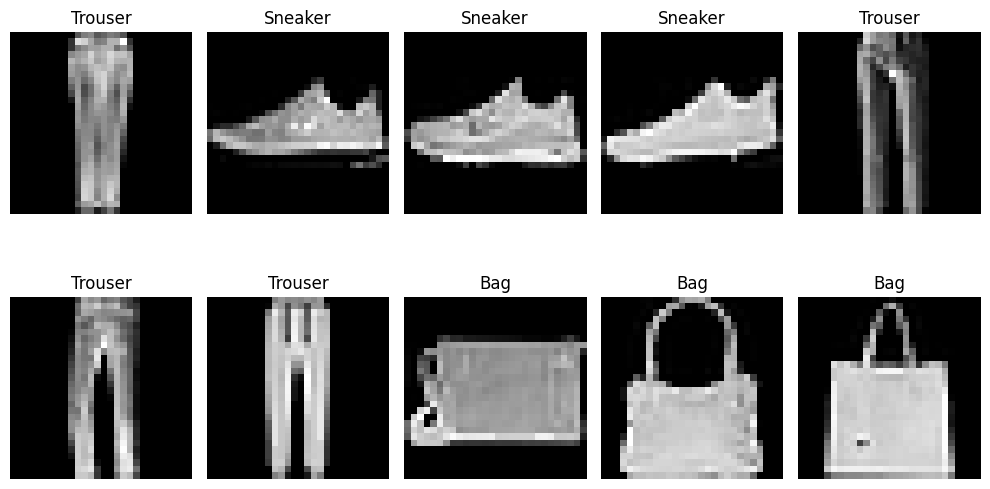

In [98]:
import matplotlib.pyplot as plt
images, labels = next(iter(train_loader))

plt.figure(figsize=(10, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    image = images[i].squeeze().numpy()

    # Undo normalization for display
    image = image * 0.5 + 0.5

    plt.imshow(image, cmap="gray")
    plt.title(CLASS_NAMES[labels[i].item()])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [99]:
import torch.nn as nn
class CNN(nn.Module):

    def __init__(self):
        super(CNN, self).__init__()

        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(
            in_channels=32,
            out_channels=64,
            kernel_size=3,
            padding=1
        )

        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(
            64 * 7 * 7,
            128
        )

        self.relu3 = nn.ReLU()

        self.fc2 = nn.Linear(
            128,
            4
        )

    def forward(self, x):

        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)

        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)

        x = x.view(x.size(0), -1)

        x = self.fc1(x)
        x = self.relu3(x)

        x = self.fc2(x)

        return x

In [100]:
import torch.optim as optim
model = CNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print(model)

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu1): ReLU()
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu2): ReLU()
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (relu3): ReLU()
  (fc2): Linear(in_features=128, out_features=4, bias=True)
)


In [101]:
def train_one_epoch(model, loader, criterion, optimizer):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [102]:
def evaluate(model, loader, criterion):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

In [103]:
EPOCHS = 10

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer
    )

    val_loss, val_acc = evaluate(
        model,
        val_loader,
        criterion
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc*100:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc*100:.2f}%"
    )

Epoch [1/10] Train Loss: 0.1025 | Train Acc: 96.83% | Val Loss: 0.0504 | Val Acc: 98.54%
Epoch [2/10] Train Loss: 0.0399 | Train Acc: 98.79% | Val Loss: 0.0562 | Val Acc: 98.04%
Epoch [3/10] Train Loss: 0.0253 | Train Acc: 99.16% | Val Loss: 0.0312 | Val Acc: 98.88%
Epoch [4/10] Train Loss: 0.0185 | Train Acc: 99.40% | Val Loss: 0.0290 | Val Acc: 99.00%
Epoch [5/10] Train Loss: 0.0136 | Train Acc: 99.58% | Val Loss: 0.0338 | Val Acc: 98.94%
Epoch [6/10] Train Loss: 0.0099 | Train Acc: 99.63% | Val Loss: 0.0350 | Val Acc: 98.92%
Epoch [7/10] Train Loss: 0.0054 | Train Acc: 99.84% | Val Loss: 0.0293 | Val Acc: 99.25%
Epoch [8/10] Train Loss: 0.0043 | Train Acc: 99.88% | Val Loss: 0.0300 | Val Acc: 99.38%
Epoch [9/10] Train Loss: 0.0069 | Train Acc: 99.76% | Val Loss: 0.0448 | Val Acc: 98.88%
Epoch [10/10] Train Loss: 0.0041 | Train Acc: 99.88% | Val Loss: 0.0297 | Val Acc: 99.21%


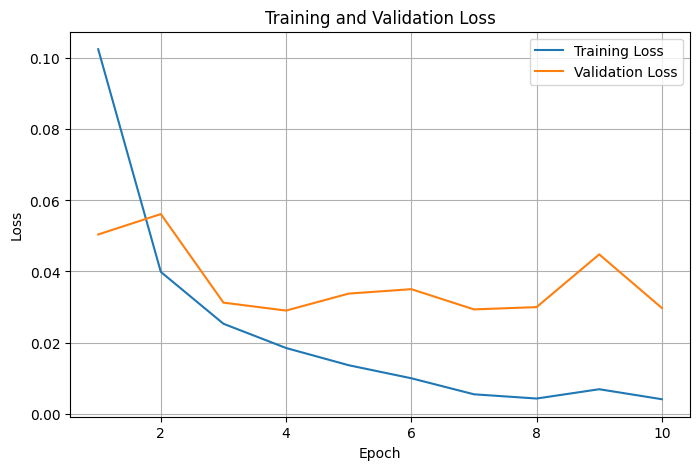

In [104]:
epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    train_losses,
    label="Training Loss"
)

plt.plot(
    epochs_range,
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid()
plt.show()

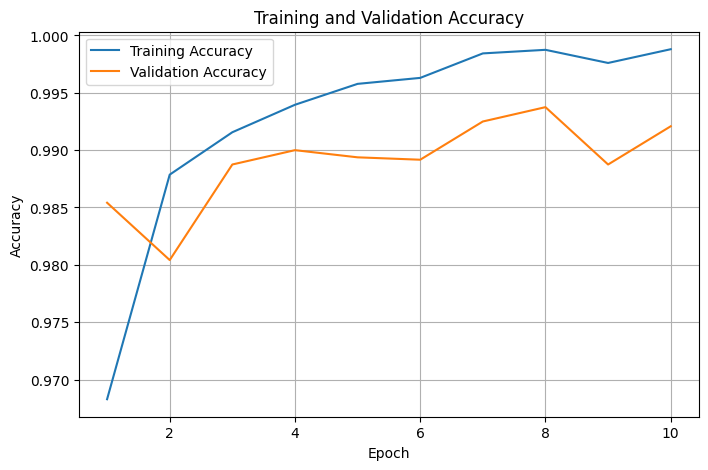

In [105]:
plt.figure(figsize=(8, 5))

plt.plot(
    epochs_range,
    train_accuracies,
    label="Training Accuracy"
)

plt.plot(
    epochs_range,
    val_accuracies,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

In [106]:
STUDENT_ID = "YOUR_ID"

MODEL_PATH = os.path.join(
    REPO_PATH,
    "model",
    f"{STUDENT_ID}.pth"
)

torch.save(
    model.state_dict(),
    MODEL_PATH
)

print("Model saved to:")
print(MODEL_PATH)

Model saved to:
/content/220120_CNN/model/YOUR_ID.pth


In [107]:
import numpy as np
model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        predictions = torch.argmax(outputs, dim=1)

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

test_accuracy = np.mean(
    np.array(all_predictions) == np.array(all_labels)
)

print(
    f"Standard FashionMNIST Test Accuracy: "
    f"{test_accuracy * 100:.2f}%"
)

Standard FashionMNIST Test Accuracy: 99.20%


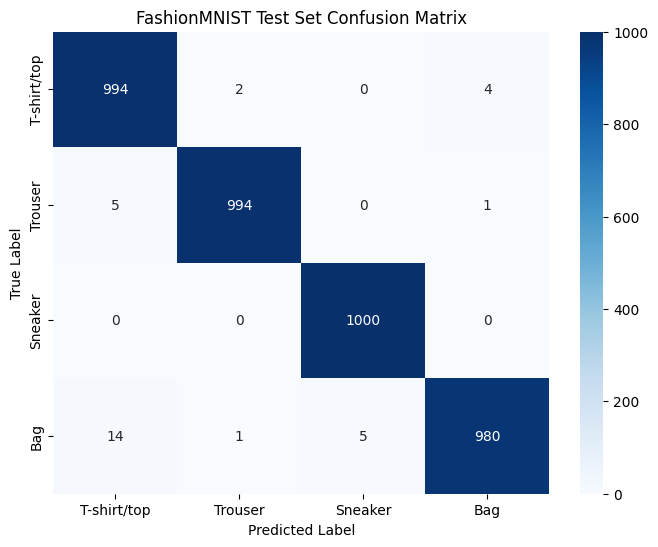

In [108]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("FashionMNIST Test Set Confusion Matrix")

plt.show()

In [109]:
incorrect_samples = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        predictions = torch.argmax(outputs, dim=1)

        for i in range(len(labels)):

            if predictions[i] != labels[i]:

                incorrect_samples.append(
                    (
                        images[i].cpu(),
                        labels[i].cpu().item(),
                        predictions[i].cpu().item()
                    )
                )

print(
    "Number of incorrect predictions:",
    len(incorrect_samples)
)

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Number of incorrect predictions: 32


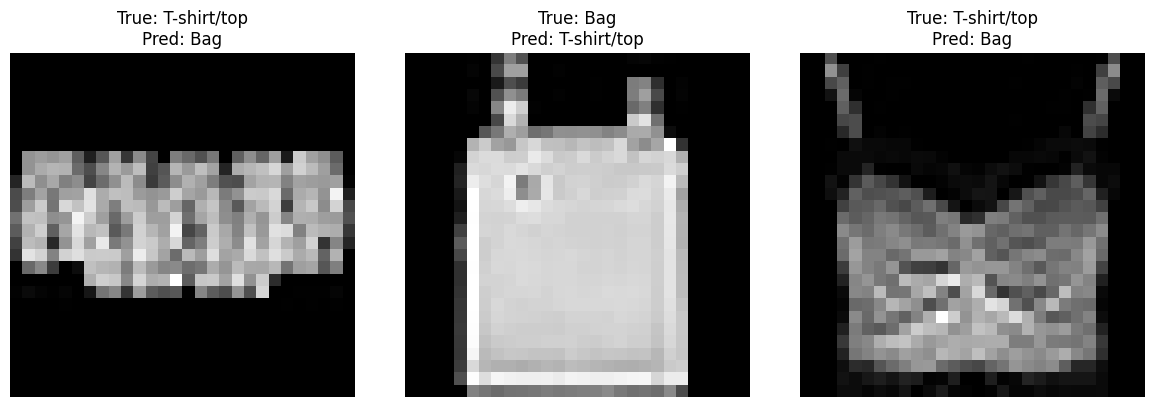

In [110]:
import random
random.seed(42)

samples = random.sample(
    incorrect_samples,
    min(3, len(incorrect_samples))
)

plt.figure(figsize=(12, 4))

for i, (image, true_label, predicted_label) in enumerate(samples):

    plt.subplot(1, 3, i + 1)

    image = image.squeeze().numpy()

    # Undo normalization
    image = image * 0.5 + 0.5

    plt.imshow(image, cmap="gray")

    plt.title(
        f"True: {CLASS_NAMES[true_label]}\n"
        f"Pred: {CLASS_NAMES[predicted_label]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [111]:
custom_images = []

for filename in sorted(os.listdir(CUSTOM_DATA_PATH)):

    if filename.lower().endswith(
        (".jpg", ".jpeg", ".png")
    ):

        custom_images.append(
            os.path.join(CUSTOM_DATA_PATH, filename)
        )

print("Custom images found:", len(custom_images))

for image_path in custom_images:
    print(os.path.basename(image_path))

Custom images found: 11
bag2.jpg
bag3.jpg
bag7.jpeg
sneaker3.jpg
sneaker9.jpeg
top1.jpg
top10.jpeg
top3.jpg
top4.jpg
touser10.jpeg
trouser3.jpg


In [112]:
custom_transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [113]:
STUDENT_ID = "220120"

MODEL_PATH = os.path.join(
    REPO_PATH,
    "model",
    f"{STUDENT_ID}.pth"
)

torch.save(model.state_dict(), MODEL_PATH)

print("Saved:", MODEL_PATH)

Saved: /content/220120_CNN/model/220120.pth


In [114]:
import os

MODEL_PATH = "/content/220120_CNN/model/220120.pth"

print(os.path.exists(MODEL_PATH))

True


In [115]:
import os

MODEL_PATH = "/content/220120_CNN/model/220120.pth"

print("File exists:", os.path.exists(MODEL_PATH))
print("Full path:", MODEL_PATH)
print("File size:", os.path.getsize(MODEL_PATH), "bytes")

File exists: True
Full path: /content/220120_CNN/model/220120.pth
File size: 1686655 bytes


In [116]:
from google.colab import files

files.download("/content/220120_CNN/model/220120.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [117]:
def predict_custom_image(image_path):

    image = Image.open(image_path).convert("RGB")

    transformed_image = custom_transform(image)

    input_tensor = transformed_image.unsqueeze(0).to(device)

    model.eval()

    with torch.no_grad():

        output = model(input_tensor)

        probabilities = torch.softmax(
            output,
            dim=1
        )

        confidence, prediction = torch.max(
            probabilities,
            dim=1
        )

    predicted_class = CLASS_NAMES[
        prediction.item()
    ]

    confidence_percentage = (
        confidence.item() * 100
    )

    return (
        image,
        predicted_class,
        confidence_percentage
    )

In [118]:
#predict one custom image
def predict_custom_image(image_path):

    image = Image.open(image_path).convert("RGB")

    transformed_image = custom_transform(image)

    input_tensor = transformed_image.unsqueeze(0).to(device)

    model.eval()

    with torch.no_grad():

        output = model(input_tensor)

        probabilities = torch.softmax(
            output,
            dim=1
        )

        confidence, prediction = torch.max(
            probabilities,
            dim=1
        )

    predicted_class = CLASS_NAMES[
        prediction.item()
    ]

    confidence_percentage = (
        confidence.item() * 100
    )

    return (
        image,
        predicted_class,
        confidence_percentage
    )

In [119]:
print("Number of images:", len(custom_images))

for image_path in custom_images:
    print(os.path.basename(image_path))

Number of images: 11
bag2.jpg
bag3.jpg
bag7.jpeg
sneaker3.jpg
sneaker9.jpeg
top1.jpg
top10.jpeg
top3.jpg
top4.jpg
touser10.jpeg
trouser3.jpg


In [120]:
from PIL import Image
custom_results = []

for image_path in custom_images:

    image, predicted_class, confidence = (
        predict_custom_image(image_path)
    )

    custom_results.append({
        "path": image_path,
        "image": image,
        "prediction": predicted_class,
        "confidence": confidence
    })

    print(
        f"{os.path.basename(image_path)} "
        f"→ {predicted_class} "
        f"({confidence:.2f}%)"
    )

bag2.jpg → Bag (60.02%)
bag3.jpg → Bag (49.08%)
bag7.jpeg → Bag (64.34%)
sneaker3.jpg → Bag (63.75%)
sneaker9.jpeg → T-shirt/top (54.68%)
top1.jpg → T-shirt/top (76.08%)
top10.jpeg → Bag (55.47%)
top3.jpg → Bag (81.77%)
top4.jpg → T-shirt/top (99.90%)
touser10.jpeg → Trouser (99.98%)
trouser3.jpg → Bag (40.08%)


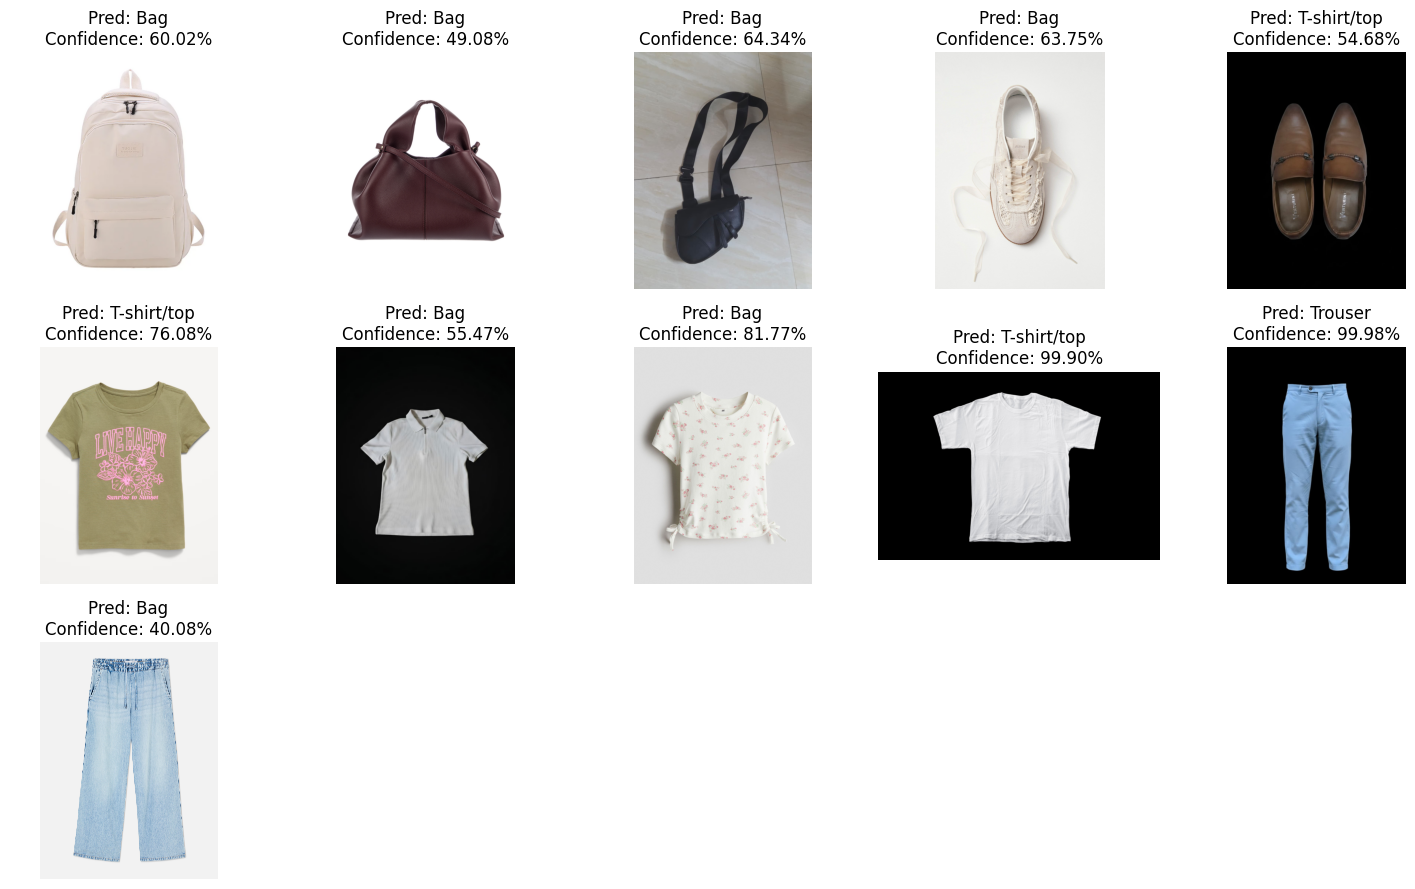

In [121]:
n = len(custom_results)

cols = 5
rows = int(np.ceil(n / cols))

plt.figure(figsize=(15, 3 * rows))

for i, result in enumerate(custom_results):

    plt.subplot(rows, cols, i + 1)

    plt.imshow(result["image"])

    plt.title(
        f"Pred: {result['prediction']}\n"
        f"Confidence: {result['confidence']:.2f}%"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [122]:
print("Final Training Accuracy:", train_accuracies[-1] * 100)
print("Final Validation Accuracy:", val_accuracies[-1] * 100)
print("Test Accuracy:", test_accuracy * 100)

Final Training Accuracy: 99.88020833333333
Final Validation Accuracy: 99.20833333333333
Test Accuracy: 99.2


In [123]:
print("=" * 60)
print("CUSTOM PHONE IMAGE RESULTS")
print("=" * 60)

for result in custom_results:

    filename = os.path.basename(
        result["path"]
    )

    print(
        f"{filename:20s} "
        f"Pred: {result['prediction']:15s} "
        f"Confidence: {result['confidence']:.2f}%"
    )

CUSTOM PHONE IMAGE RESULTS
bag2.jpg             Pred: Bag             Confidence: 60.02%
bag3.jpg             Pred: Bag             Confidence: 49.08%
bag7.jpeg            Pred: Bag             Confidence: 64.34%
sneaker3.jpg         Pred: Bag             Confidence: 63.75%
sneaker9.jpeg        Pred: T-shirt/top     Confidence: 54.68%
top1.jpg             Pred: T-shirt/top     Confidence: 76.08%
top10.jpeg           Pred: Bag             Confidence: 55.47%
top3.jpg             Pred: Bag             Confidence: 81.77%
top4.jpg             Pred: T-shirt/top     Confidence: 99.90%
touser10.jpeg        Pred: Trouser         Confidence: 99.98%
trouser3.jpg         Pred: Bag             Confidence: 40.08%


In [124]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        predictions = torch.argmax(outputs, dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Classification report
print(classification_report(
    all_labels,
    all_predictions,
    target_names=CLASS_NAMES,
    digits=4
))

              precision    recall  f1-score   support

 T-shirt/top     0.9812    0.9940    0.9876      1000
     Trouser     0.9970    0.9940    0.9955      1000
     Sneaker     0.9950    1.0000    0.9975      1000
         Bag     0.9949    0.9800    0.9874      1000

    accuracy                         0.9920      4000
   macro avg     0.9920    0.9920    0.9920      4000
weighted avg     0.9920    0.9920    0.9920      4000



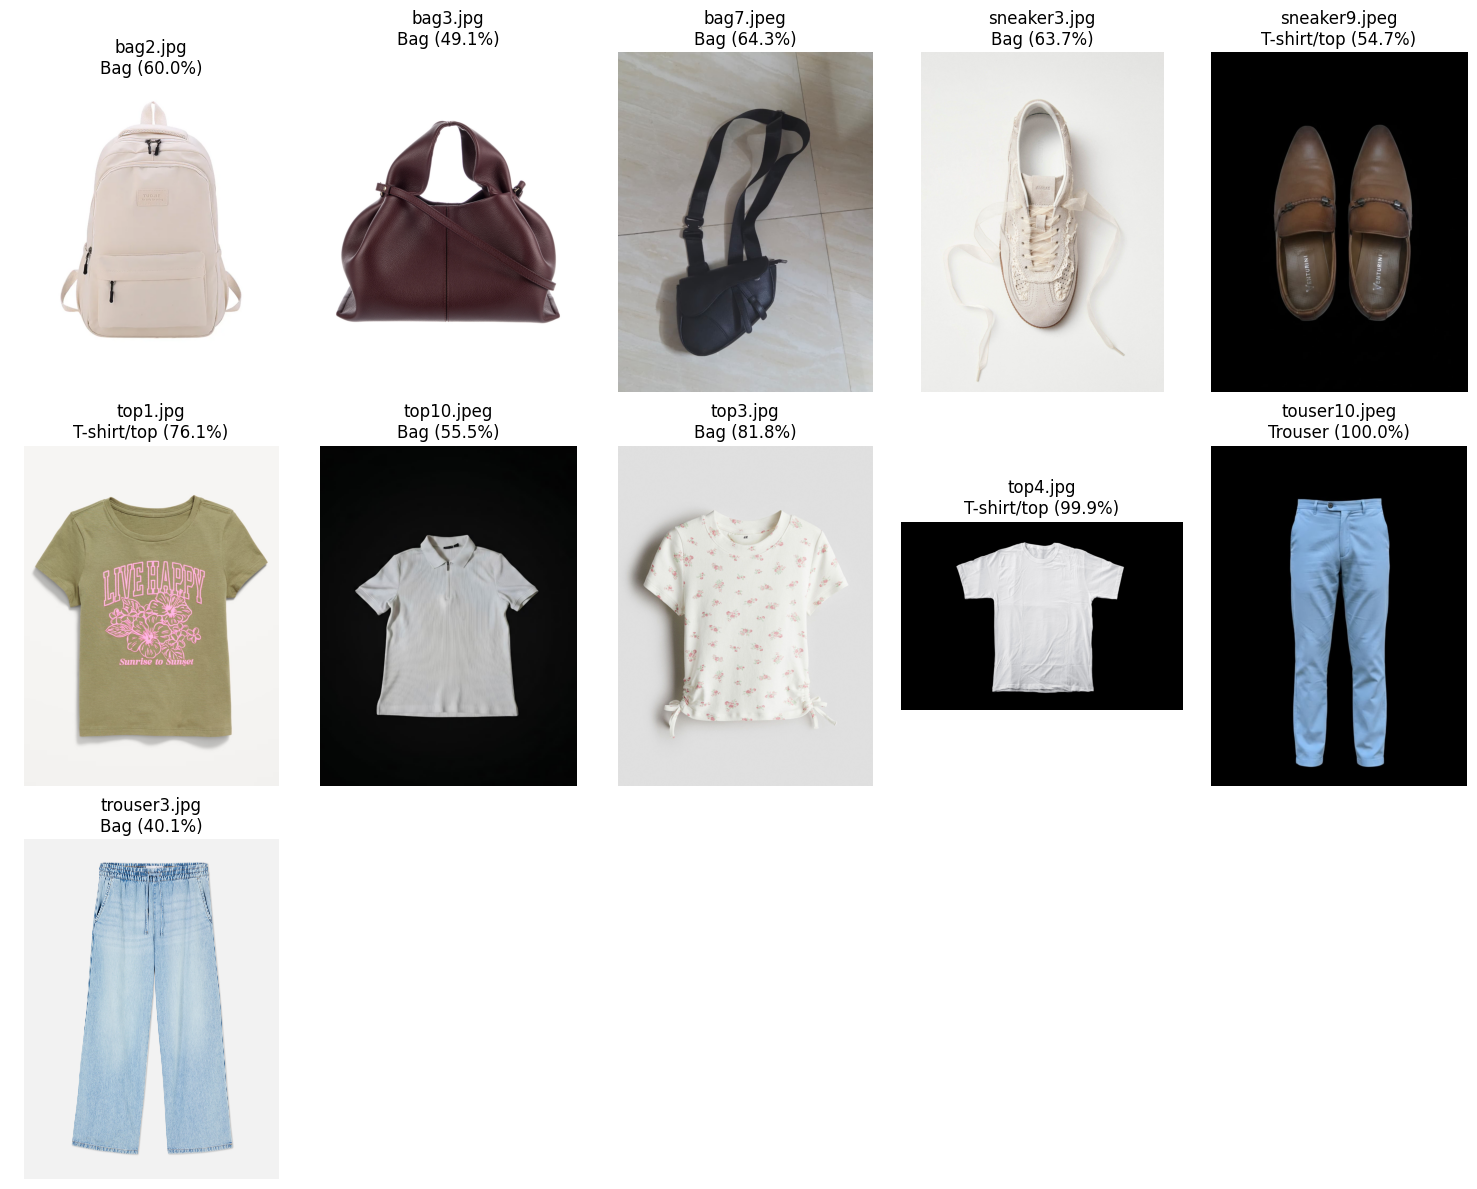

In [125]:
import math

num_images = len(custom_results)
cols = 5
rows = math.ceil(num_images / cols)

plt.figure(figsize=(15, 4 * rows))

for i, result in enumerate(custom_results):

    plt.subplot(rows, cols, i + 1)

    plt.imshow(result["image"])

    filename = os.path.basename(result["path"])

    plt.title(
        f"{filename}\n"
        f"{result['prediction']} "
        f"({result['confidence']:.1f}%)"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [126]:
print("Model file exists:", os.path.exists(MODEL_PATH))
print("Model path:", MODEL_PATH)

if os.path.exists(MODEL_PATH):
    print(
        "Model size:",
        os.path.getsize(MODEL_PATH),
        "bytes"
    )

Model file exists: True
Model path: /content/220120_CNN/model/220120.pth
Model size: 1686655 bytes


In [127]:
print("Repository contents:\n")

for root, dirs, files in os.walk(REPO_PATH):

    level = root.replace(REPO_PATH, "").count(os.sep)

    indent = "    " * level

    print(f"{indent}{os.path.basename(root)}/")

    for file in files:
        print(f"{indent}    {file}")

Repository contents:

220120_CNN/
    README.md
    220120_CNN.ipynb
    custom dataset/
        bag2.jpg
        sneaker3.jpg
        trouser3.jpg
        top1.jpg
        top10.jpeg
        top4.jpg
        touser10.jpeg
        sneaker9.jpeg
        bag3.jpg
        top3.jpg
        bag7.jpeg
    results/
        error_analysis.png
        accuracy.png
        loss.png
        confusion_matrix.png
        custom_predictions.png
    model/
        220120 (1).pth
        YOUR_ID.pth
        220120.pth
    .git/
        description
        HEAD
        index
        packed-refs
        config
        hooks/
            prepare-commit-msg.sample
            update.sample
            pre-merge-commit.sample
            pre-applypatch.sample
            pre-commit.sample
            pre-receive.sample
            push-to-checkout.sample
            post-update.sample
            commit-msg.sample
            pre-push.sample
            applypatch-msg.sample
            pre-rebase.sample
 